<a href="https://colab.research.google.com/github/DianaDoosti-PouyanBahmani/Intelligent-Systems/blob/main/mini%20project%202/MP2_Q7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Dataset downloaded to: /kaggle/input/breast-cancer-wisconsin-data
X shape: (569, 30)
y shape: (569,)
Train: (341, 30)
Validation: (114, 30)
Test: (114, 30)


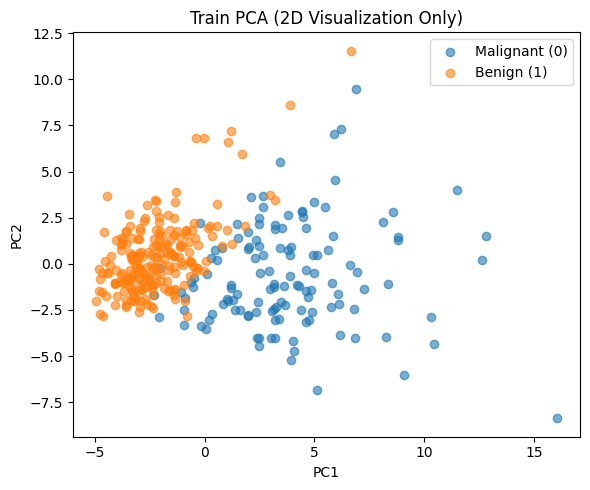

C=0.01: Validation Accuracy = 0.9561
C=0.1: Validation Accuracy = 0.9912
C=1: Validation Accuracy = 0.9912
C=10: Validation Accuracy = 0.9737
C=100: Validation Accuracy = 0.9737

Best C based on Validation: 0.1

w (coef_): [-0.15540186 -0.1941911  -0.14278417 -0.16554388 -0.0817098   0.06587148
 -0.28745581 -0.30739141  0.08429179  0.11925508 -0.29045587  0.21842824
 -0.19937344 -0.25128628 -0.12222732  0.18518358 -0.04121831  0.03281466
  0.03340127  0.14849511 -0.41545296 -0.57796026 -0.38292185 -0.38173669
 -0.35300911  0.05759255 -0.2434324  -0.34027188 -0.28691643 -0.05570804]
b: 0.2468892778996617
||w||: 1.3478322632508521
Margin = 1/||w|| = 0.7419320840325402

w from dual (should match coef_):
[-0.15540186 -0.1941911  -0.14278417 -0.16554388 -0.0817098   0.06587148
 -0.28745581 -0.30739141  0.08429179  0.11925508 -0.29045587  0.21842824
 -0.19937344 -0.25128628 -0.12222732  0.18518358 -0.04121831  0.03281466
  0.03340127  0.14849511 -0.41545296 -0.57796026 -0.38292185 -0.3817366

In [ ]:
# -*- coding: utf-8 -*-
"""
SVM خطی + مطالعه پارامتر C
دیتاست: Breast Cancer Wisconsin (Kaggle)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)

# ------------------------------------------------------
# ۱) دانلود دیتاست از Kaggle
# ------------------------------------------------------
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Dataset downloaded to:", path)

csv_path = path + "/data.csv"   # فایل اصلی دیتاست
df = pd.read_csv(csv_path)

# ------------------------------------------------------
# ۲) پیش‌پردازش
# ------------------------------------------------------

# حذف ستون‌های بی‌مصرف
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

# diagnosis → تبدیل به 0/1
df["diagnosis"] = df["diagnosis"].map({"M": 0, "B": 1})

X = df.drop(columns=["diagnosis"]).values
y = df["diagnosis"].values

print("X shape:", X.shape)
print("y shape:", y.shape)


RANDOM_STATE = 13

# ابتدا جدا کردن test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# سپس جدا کردن validation از ۸۰٪ باقی‌مانده
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,          # 0.25 * 0.8 = 0.2 کل
    stratify=y_train_val,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# ------------------------------------------------------
# ۴) استانداردسازی (fit فقط روی train)
# ------------------------------------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# ------------------------------------------------------
# ۵) PCA دوبعدی فقط برای نمایش
# ------------------------------------------------------
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca2 = pca.fit_transform(X_train_s)

plt.figure(figsize=(6,5))
plt.scatter(X_train_pca2[y_train==0,0], X_train_pca2[y_train==0,1],
            alpha=0.6, label="Malignant (0)")
plt.scatter(X_train_pca2[y_train==1,0], X_train_pca2[y_train==1,1],
            alpha=0.6, label="Benign (1)")
plt.title("Train PCA (2D Visualization Only)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# ۶) مطالعه پارامتر C
# ------------------------------------------------------
C_values = [0.01, 0.1, 1, 10, 100]
best_acc = -1
best_clf = None
best_C = None

for C in C_values:
    clf = SVC(kernel="linear", C=C, random_state=RANDOM_STATE)
    clf.fit(X_train_s, y_train)

    y_val_pred = clf.predict(X_val_s)
    acc = accuracy_score(y_val, y_val_pred)

    print(f"C={C}: Validation Accuracy = {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_clf = clf
        best_C = C

print("\nBest C based on Validation:", best_C)

# ------------------------------------------------------
# ۷) استخراج w, b و محاسبه Margin
# ------------------------------------------------------
w = best_clf.coef_[0]
b = best_clf.intercept_[0]

norm_w = np.linalg.norm(w)
margin = 1 / norm_w

print("\nw (coef_):", w)
print("b:", b)
print("||w||:", norm_w)
print("Margin = 1/||w|| =", margin)

# بررسی رابطه w = Σ α_i y_i x_i (اختیاری)
alphas = best_clf.dual_coef_[0]
SV = best_clf.support_vectors_
w_dual = np.sum(alphas[:, None] * SV, axis=0)
print("\nw from dual (should match coef_):")
print(w_dual)

# ------------------------------------------------------
# ۸) ارزیابی روی validation & test
# ------------------------------------------------------
def report(name, y_true, y_pred, scores):
    print(f"\n{name} RESULTS:")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, scores))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred))

# Validation
y_val_pred = best_clf.predict(X_val_s)
val_scores = best_clf.decision_function(X_val_s)
report("VALIDATION", y_val, y_val_pred, val_scores)

# Test
y_test_pred = best_clf.predict(X_test_s)
test_scores = best_clf.decision_function(X_test_s)
report("TEST", y_test, y_test_pred, test_scores)

In [ ]:
# TRAIN metrics
y_train_pred = best_clf.predict(X_train_s)
train_scores = best_clf.decision_function(X_train_s)

print("TRAIN RESULTS:")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1-score :", f1_score(y_train, y_train_pred))
print("ROC-AUC  :", roc_auc_score(y_train, train_scores))

TRAIN RESULTS:
Accuracy : 0.9824046920821115
Precision: 0.9770642201834863
Recall   : 0.9953271028037384
F1-score : 0.9861111111111112
ROC-AUC  : 0.9988593715505187


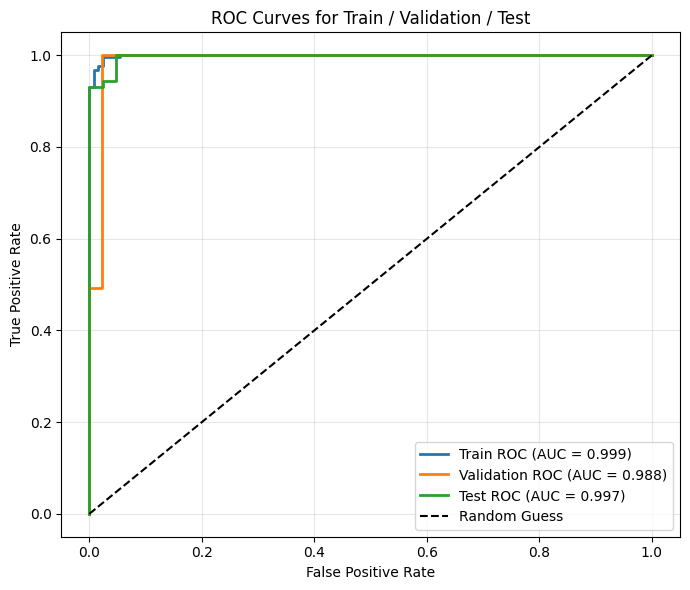

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# -------------------------------
# نمره‌های مدل (decision_function)
# -------------------------------
train_scores = best_clf.decision_function(X_train_s)
val_scores   = best_clf.decision_function(X_val_s)
test_scores  = best_clf.decision_function(X_test_s)

# -------------------------------
# ROC برای Train
# -------------------------------
fpr_train, tpr_train, _ = roc_curve(y_train, train_scores)
auc_train = auc(fpr_train, tpr_train)

# -------------------------------
# ROC برای Validation
# -------------------------------
fpr_val, tpr_val, _ = roc_curve(y_val, val_scores)
auc_val = auc(fpr_val, tpr_val)

# -------------------------------
# ROC برای Test
# -------------------------------
fpr_test, tpr_test, _ = roc_curve(y_test, test_scores)
auc_test = auc(fpr_test, tpr_test)

# -------------------------------
# رسم همه در یک نمودار
# -------------------------------
plt.figure(figsize=(7,6))

plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.3f})", linewidth=2)
plt.plot(fpr_val,   tpr_val,   label=f"Validation ROC (AUC = {auc_val:.3f})", linewidth=2)
plt.plot(fpr_test,  tpr_test,  label=f"Test ROC (AUC = {auc_test:.3f})", linewidth=2)

# خط حدس تصادفی
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Train / Validation / Test")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

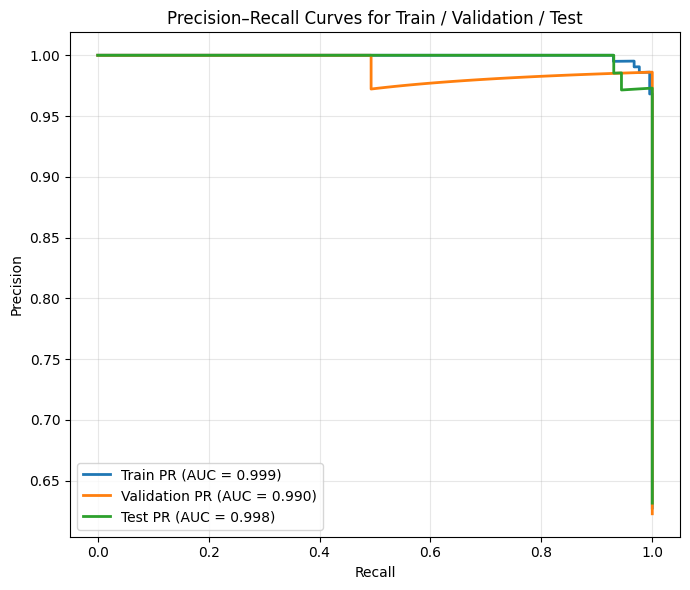

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# -------------------------------
# نمره‌های مدل روی سه مجموعه
# -------------------------------
train_scores = best_clf.decision_function(X_train_s)
val_scores   = best_clf.decision_function(X_val_s)
test_scores  = best_clf.decision_function(X_test_s)

# -------------------------------
# PR برای Train
# -------------------------------
precision_train, recall_train, _ = precision_recall_curve(y_train, train_scores)
auc_pr_train = auc(recall_train, precision_train)

# -------------------------------
# PR برای Validation
# -------------------------------
precision_val, recall_val, _ = precision_recall_curve(y_val, val_scores)
auc_pr_val = auc(recall_val, precision_val)

# -------------------------------
# PR برای Test
# -------------------------------
precision_test, recall_test, _ = precision_recall_curve(y_test, test_scores)
auc_pr_test = auc(recall_test, precision_test)

# -------------------------------
# رسم همه در یک نمودار
# -------------------------------
plt.figure(figsize=(7,6))

plt.plot(recall_train, precision_train,
         label=f"Train PR (AUC = {auc_pr_train:.3f})", linewidth=2)

plt.plot(recall_val, precision_val,
         label=f"Validation PR (AUC = {auc_pr_val:.3f})", linewidth=2)

plt.plot(recall_test, precision_test,
         label=f"Test PR (AUC = {auc_pr_test:.3f})", linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves for Train / Validation / Test")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
